In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
from pathlib import Path
import sys  

# Get my_package directory path from Notebook
parent_dir = str(Path().resolve().parents[0])

# Add to sys.path
sys.path.insert(0, parent_dir)


In [13]:
from utils.experiment_utils import get_all_experiments_info, load_best_model

device = 'cuda'
configs = get_all_experiments_info('../outputs/', False)
cfgs = [
    c for c in configs if 'handwriting' in c['name'] 
    and c['config']['training']['num_epochs'] == 1000
]   


In [14]:
cfgs

[{'name': 'handwriting_exp_68dae050ec2c090ae285dd76c200fd2b',
  'dir': '../outputs/handwriting_exp_68dae050ec2c090ae285dd76c200fd2b',
  'config': {'dataset': {'_target_': 'datasets.handwriting.HandwritingDataset', 'set_size': '${experiment.set_size}', 'data_shape': [1, 32, 32], 'seed': '${seed}'}, 'encoder': {'_target_': 'encoder.conv_gnn.ConvDistributionEncoder', 'in_channels': '${dataset.data_shape[0]}', 'hidden_channels': 64, 'out_channels': 32, 'hidden_dim': '${experiment.hidden_dim}', 'latent_dim': '${experiment.latent_dim}', 'num_layers': 3, 'kernel_size': 3, 'height': '${dataset.data_shape[1]}', 'width': '${dataset.data_shape[2]}', 'pool_type': 'mean', 'agg_type': 'mean'}, 'model': {'_target_': 'model.unet.ContextUnet', 'in_channels': 1, 'n_feat': 128, 'latent_dim': 128, 'image_size': 32}, 'coupling': {'_target_': 'types.NoneType'}, 'generator': {'_target_': 'generator.flow_matching.FlowMatchingGenerator', 'model': '${model}', 'sigma_min': 0.0001}, 'optimizer': {'_target_': 'tor

In [15]:
import hydra
# load + prep dataset
def prepare_dataset(dataset_cfg):
    # probs = np.column_stack((np.linspace(0, 1, num_probs), 1 - np.linspace(0, 1, num_probs)))
    dataset = hydra.utils.instantiate(dataset_cfg)
    # dataset.probs = probs
    # dataset.data, _, _ = dataset.make_sets()
    return dataset

# load encoder and move to device
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

enc, gen = load_model(cfgs[0]['config'], cfgs[0]['dir'], device)

In [6]:
ds = prepare_dataset(cfgs[0]['config']['dataset'])

In [16]:
batch = next(iter(ds))

In [17]:
import numpy as np
import torch
source_samples = batch['source_samples']
target_samples = batch['target_samples']
source_latent, target_latent = enc(
    torch.from_numpy(np.concatenate([source_samples[None, ...], target_samples[None, ...]], axis=0)).float().to(device)
)

resample = gen.sample(source_samples.to(device), source_latent.unsqueeze(0), target_latent.unsqueeze(0)).squeeze(0)

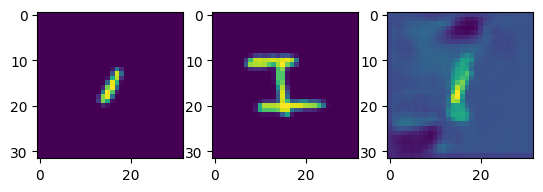

In [22]:
import matplotlib.pyplot as plt
# visualize 3 channel image
source_samples = batch['source_samples']
target_samples = batch['target_samples']
i = -14
fig, axs = plt.subplots(1, 3)
axs[0].imshow(source_samples[i].cpu().numpy().transpose(1, 2, 0))
axs[1].imshow(target_samples[i].cpu().numpy().transpose(1, 2, 0))
axs[2].imshow(resample[i].cpu().numpy().transpose(1, 2, 0))
plt.show()